1. Python code for data profiling.

In [1]:
import pandas as pd
from ydata_profiling import ProfileReport

df = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\red_wine.csv")
profile = ProfileReport(df, title="Red Wine Quality Profiling Report")
profile.to_file("red_wine_quality_report.html")
print("Report generated! Open red_wine_quality_report.html in your browser.")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report generated! Open red_wine_quality_report.html in your browser.


2.	Fit a model using each of the following methods and report the performance metrics of 10-fold cross-validation using red-wine.csv as the training set. 

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\red_wine.csv")

le = LabelEncoder()
y = le.fit_transform(df["type"])
X = df.drop("type", axis=1)

baseline_acc = max(df["type"].value_counts(normalize=True))

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM-Linear": SVC(kernel="linear", probability=True),  
    "SVM-RBF": SVC(kernel="rbf", probability=True),        
    "Random Forest": RandomForestClassifier()
}

results = {"Model": [], "AUC": [], "Accuracy": []}
for name, model in models.items():

    acc_scores = cross_val_score(model, X, y, cv=10, scoring="accuracy")
    avg_acc = np.round(np.mean(acc_scores), 3)

    auc_scores = cross_val_score(model, X, y, cv=10, scoring="roc_auc")
    avg_auc = np.round(np.mean(auc_scores), 3)

    results["Model"].append(name)
    results["Accuracy"].append(avg_acc)
    results["AUC"].append(avg_auc)

results_df = pd.DataFrame(results)
print("\n" + "="*40 + " Results " + "="*40)
print(results_df.to_string(index=False))
print("="*89)


======================================== Results ========================================
              Model   AUC  Accuracy
Logistic Regression 0.880     0.785
        Naive Bayes 0.895     0.822
      Decision Tree 0.756     0.757
         SVM-Linear 0.881     0.792
            SVM-RBF 0.869     0.536
      Random Forest 0.889     0.790


3.	Plot the ROC curve of the Random Forest classifier from the Python package.

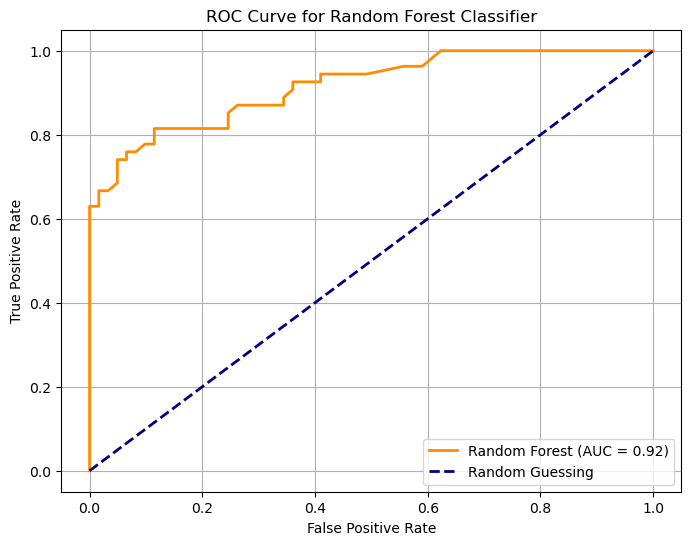

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\red_wine.csv")
le = LabelEncoder()
y = le.fit_transform(df["type"]) 
X = df.drop("type", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_probs = rf.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Random Forest (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


4.	Using the naive bayes to run the model on white-wine.csv.

In [3]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

df_white = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\white_wine.csv")
print("\nFirst 5 rows of white wine dataset:")
print(df_white.head().to_string(index=False))

le = LabelEncoder()
y_white = le.fit_transform(df_white["type"])  # low=0, high=1
X_white = df_white.drop("type", axis=1)

nb = GaussianNB()
auc_scores = cross_val_score(nb, X_white, y_white, cv=10, scoring="roc_auc")
accuracy_scores = cross_val_score(nb, X_white, y_white, cv=10, scoring="accuracy")
avg_auc = round(auc_scores.mean(), 3)
avg_accuracy = round(accuracy_scores.mean(), 3)

print("\nPerformance " )
print(f"Naive Bayes on White Wine:")
print(f"Average AUC: {avg_auc}")
print(f"Average Accuracy: {avg_accuracy}")





First 5 rows of white wine dataset:
 citric acid  sulphates  alcohol type
        0.24       0.52      9.4  low
        0.49       0.56      9.4  low
        0.66       0.73     10.0  low
        0.32       0.77     10.0  low
        0.38       0.82     10.0  low

Performance 
Naive Bayes on White Wine:
Average AUC: 0.95
Average Accuracy: 0.932
